In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import digamma
from scipy.stats import t

# Creación del Dataset

Se desea modelar el tiempo (en minutos con respecto a la hora de entrada) en que diferentes grupos
de estudiantes llegan a una determinada clase de la facultad. Estos comportamientos ser´an modelados
como una mezcla de 6 comportamientos distintos dentro de las rutinas de las personas.

En realidad existían 4 comportamientos marcados (aunque nosotros no lo sabíamos). Ellos pueden pensarse como:

- Un 10 % de personas muy puntuales (μ = −4 y varianza más pequeña).
- Un 40 % de personas que tienden a llegar justo (μ = 0).
- Un 20 % de personas “relajadas” (μ = 4).
- Un 30 % de personas consistentemente impuntuales (μ = 5 y varianza más pequeña).

In [2]:
# Parámetros de la mezcla
pesos = np.array([0.1, 0.4, 0.2, 0.3])
medias = np.array([-4, 0, 4, 5])
varianzas = np.array([1, 1.96, 1.44, 1])

# Desvíos estándar
sigmas = np.sqrt(varianzas)

# Cantidad de muestras
N = 100

# Elegir para cada muestra qué componente genera el dato
np.random.seed(10072003)
componentes = np.random.choice(
    len(pesos),
    size=N,
    p=pesos
)

# Generar las muestras
muestras = np.random.normal(
    loc=medias[componentes],
    scale=sigmas[componentes]
)

print(muestras)

[ 4.48200652  5.9717652   1.36839797  5.24755954  5.61224526  5.44014793
 -1.15603241  3.97392181  1.52881605 -4.73861113  3.85507273 -1.71352813
  0.70314934 -0.77720289  3.30313383  2.05598556  0.49024774  0.75903013
  2.17663071 -0.06419631  3.14930861  3.82796331  5.34445473  2.81886066
  4.83370963 -0.47169216 -0.70723334  3.73781449  3.34589665 -0.17696165
  3.45005776  6.79223169  5.52055943 -0.6883784   1.09712384  0.95672136
  0.13780399  3.7219836  -1.66716583  5.02382817  4.81245293  3.21307341
  3.83238932  6.26583295 -3.55510327 -1.19042247  7.56747137  7.630104
  4.25227027  1.36093581  4.17029358  1.38718613  4.2661181   1.06876981
  3.99906585  5.66349372 -1.05305641  3.75516634 -2.41812368 -0.02016991
 -5.87350037  6.12061223  5.1036203   4.62953691  1.14141839  3.18011452
 -1.30138364  4.59880558  5.39632869  3.25691539 -0.21909402  6.36488344
  6.17025451  5.68224584 -3.90879184  3.814875    4.96959732  0.52439294
 -3.24933314  1.56271141  5.92598199 -0.9157553   5.2

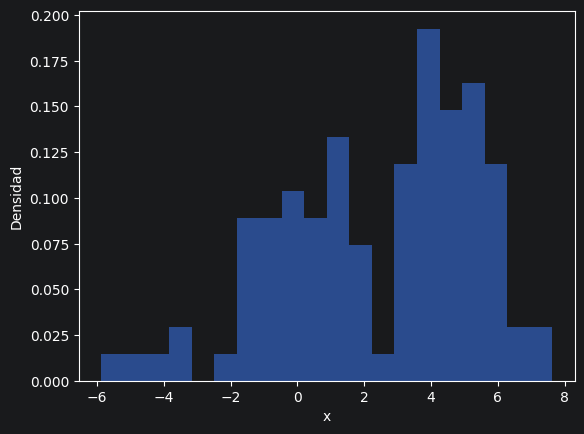

In [3]:
plt.hist(muestras, bins=20, density=True, alpha=0.6)
plt.xlabel('x')
plt.ylabel('Densidad')
plt.show()

# Primer paso con Kmeans

In [4]:
class KMeans:
    def __init__(self, n_clusters, max_iter=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        rng = np.random.default_rng(self.random_state)

        # Inicialización aleatoria de centroides
        idx = rng.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx].copy()

        for _ in range(self.max_iter):

            # Asignación de clusters
            distances = np.linalg.norm(
                X[:, np.newaxis] - self.centroids,
                axis=2
            )
            labels = np.argmin(distances, axis=1)

            # Actualización de centroides
            new_centroids = np.array([
                X[labels == k].mean(axis=0)
                if np.any(labels == k)
                else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            # Condición de convergencia
            shift = np.linalg.norm(new_centroids - self.centroids)

            self.centroids = new_centroids

            if shift < self.tol:
                break

        self.labels_ = labels

    def predict(self, X):
        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        distances = np.linalg.norm(
            X[:, np.newaxis] - self.centroids,
            axis=2
        )

        return np.argmin(distances, axis=1)

In [5]:
kmeans = KMeans(
    n_clusters=6,
    max_iter=100,
    tol=1e-4,
    random_state=10072003
)

kmeans.fit(muestras)

clusters = kmeans.predict(muestras)

Luego de tener el clusterizado hecho por kmeans, para obtener la pdf asociada, se pueden obtener los pesos, las medias y las varianzas como:

- Pesos: son la proporción del total que representa cada cluster.
- Medias: son los centroides de cada cluster.
- Varianzas: son la varianza dentro de cada cluster.

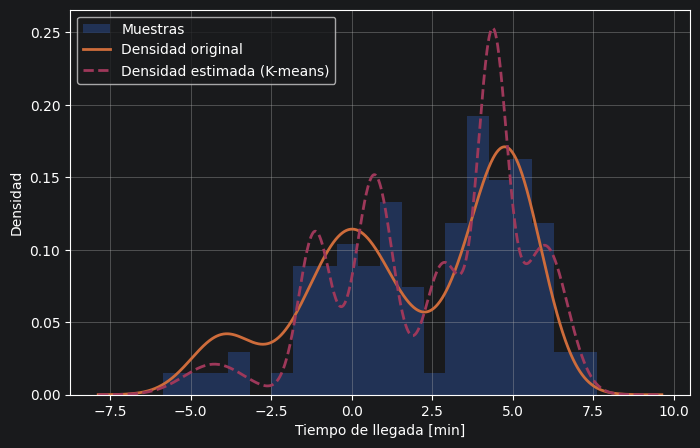

In [6]:
# Grilla para evaluar densidades
x = np.linspace(muestras.min() - 2, muestras.max() + 2, 1000)

# Densidad original
pesos_true = np.array([0.1, 0.4, 0.2, 0.3])
medias_true = np.array([-4, 0, 4, 5])
varianzas_true = np.array([1, 1.96, 1.44, 1])

densidad_original = np.zeros_like(x)

for w, mu, var in zip(pesos_true, medias_true, varianzas_true):
    densidad_original += w * norm.pdf(x, mu, np.sqrt(var))

# Densidad estimada por K-means
densidad_kmeans = np.zeros_like(x)

for k in range(kmeans.n_clusters):

    cluster = muestras[kmeans.labels_ == k]

    if len(cluster) == 0:
        continue

    peso = len(cluster) / len(muestras)
    media = kmeans.centroids[k, 0]
    varianza = np.var(cluster)

    densidad_kmeans += peso * norm.pdf(
        x,
        media,
        np.sqrt(varianza)
    )

# Gráfico
plt.figure(figsize=(8, 5))

plt.hist(
    muestras,
    bins=20,
    density=True,
    alpha=0.3,
    label="Muestras"
)

plt.plot(
    x,
    densidad_original,
    linewidth=2,
    label="Densidad original"
)

plt.plot(
    x,
    densidad_kmeans,
    "--",
    linewidth=2,
    label="Densidad estimada (K-means)"
)

plt.xlabel("Tiempo de llegada [min]")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()

# Segundo paso con EM

In [7]:
import numpy as np
from scipy.stats import norm


class GaussianMixtureEM:
    def __init__(
        self,
        n_components,
        max_iter=100,
        tol=1e-6,
        random_state=None
    ):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.weights_ = None
        self.means_ = None
        self.vars_ = None

        self.resp_ = None
        self.log_likelihood_ = []

    def _initialize_from_kmeans(self, X):
        kmeans = KMeans(
            n_clusters=self.n_components,
            max_iter=100,
            tol=1e-4,
            random_state=self.random_state
        )

        kmeans.fit(X)

        labels = kmeans.labels_

        self.weights_ = np.zeros(self.n_components)
        self.means_ = np.zeros(self.n_components)
        self.vars_ = np.zeros(self.n_components)

        for k in range(self.n_components):
            cluster = X[labels == k]

            self.weights_[k] = len(cluster) / len(X)

            if len(cluster) > 0:
                self.means_[k] = np.mean(cluster)
                self.vars_[k] = np.var(cluster)
            else:
                self.means_[k] = np.random.choice(X)
                self.vars_[k] = np.var(X)

        self.vars_ = np.maximum(self.vars_, 1e-6)

    def fit(self, X):
        X = np.asarray(X).flatten()

        self._initialize_from_kmeans(X)

        prev_ll = -np.inf

        for _ in range(self.max_iter):

            # E-step
            responsibilities = np.zeros(
                (len(X), self.n_components)
            )

            for k in range(self.n_components):
                responsibilities[:, k] = (
                    self.weights_[k]
                    * norm.pdf(
                        X,
                        self.means_[k],
                        np.sqrt(self.vars_[k])
                    )
                )

            responsibilities /= (
                responsibilities.sum(axis=1, keepdims=True)
                + 1e-12
            )

            # M-step
            Nk = responsibilities.sum(axis=0)

            self.weights_ = Nk / len(X)

            self.means_ = (
                responsibilities.T @ X
            ) / Nk

            self.vars_ = np.zeros(self.n_components)

            for k in range(self.n_components):
                diff = X - self.means_[k]

                self.vars_[k] = (
                    responsibilities[:, k]
                    @ (diff**2)
                ) / Nk[k]

            self.vars_ = np.maximum(self.vars_, 1e-6)

            # Log-likelihood
            mixture_pdf = np.zeros(len(X))

            for k in range(self.n_components):
                mixture_pdf += (
                    self.weights_[k]
                    * norm.pdf(
                        X,
                        self.means_[k],
                        np.sqrt(self.vars_[k])
                    )
                )

            ll = np.sum(np.log(mixture_pdf + 1e-12))
            self.log_likelihood_.append(ll)

            # Condición de convergencia
            if np.abs(ll - prev_ll) < self.tol:
                break

            prev_ll = ll

        self.resp_ = responsibilities

    def predict_proba(self, X):
        X = np.asarray(X).flatten()

        responsibilities = np.zeros(
            (len(X), self.n_components)
        )

        for k in range(self.n_components):
            responsibilities[:, k] = (
                self.weights_[k]
                * norm.pdf(
                    X,
                    self.means_[k],
                    np.sqrt(self.vars_[k])
                )
            )

        responsibilities /= (
            responsibilities.sum(axis=1, keepdims=True)
            + 1e-12
        )

        return responsibilities

    def predict(self, X):
        return np.argmax(
            self.predict_proba(X),
            axis=1
        )

In [8]:
gmm = GaussianMixtureEM(
    n_components=6,
    max_iter=200,
    tol=1e-6,
    random_state=10072003
)

gmm.fit(muestras)

labels = gmm.predict(muestras)
probabilidades = gmm.predict_proba(muestras)

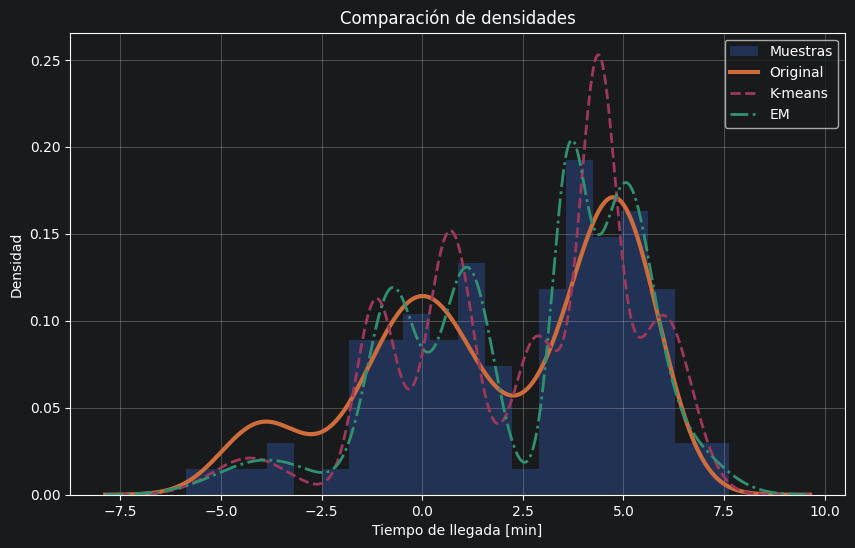

In [9]:
# Grilla
x = np.linspace(
    muestras.min() - 2,
    muestras.max() + 2,
    1000
)

# ==================================================
# Densidad estimada por EM
# ==================================================

densidad_em = np.zeros_like(x)

for k in range(gmm.n_components):

    media = gmm.means_[k]
    varianza = gmm.vars_[k]

    densidad_em += (
        gmm.weights_[k]
        * norm.pdf(
            x,
            media,
            np.sqrt(varianza)
        )
    )

# ==================================================
# Gráfico
# ==================================================

plt.figure(figsize=(10, 6))

plt.hist(
    muestras,
    bins=20,
    density=True,
    alpha=0.3,
    label="Muestras"
)

plt.plot(
    x,
    densidad_original,
    linewidth=3,
    label="Original"
)

plt.plot(
    x,
    densidad_kmeans,
    "--",
    linewidth=2,
    label="K-means"
)

plt.plot(
    x,
    densidad_em,
    "-.",
    linewidth=2,
    label="EM"
)

plt.xlabel("Tiempo de llegada [min]")
plt.ylabel("Densidad")
plt.title("Comparación de densidades")
plt.grid(True)
plt.legend()

plt.show()

# Tercer paso con GVB

 Interpretando su red bayesiana, la distribución del modelo puede escribirse como

$$p(\mathbf{x}, \mathbf{u}, \pi, \lambda, \mu) = p(\pi) \left( \prod_{k=1}^{K} p(\lambda_k) p(\mu_k | \lambda_k) \right) \left( \prod_{i=1}^{n} P(u_i | \pi) p(x_i | u_i, \mu, \lambda) \right)$$

Donde $$ \pi \sim \operatorname{Dir}(\alpha), \, \lambda_k \sim \Gamma(\nu, \beta) \text{ y } \mu_k | \lambda_k \sim \mathcal{N}(m, (\delta \lambda_k)^{-1}).$$




## Parámetros variacionales

Durante el entrenamiento se actualizan los siguientes parámetros variacionales para cada componente:

$$
\alpha_k^*
$$

$$
m_k^*
$$

$$
\delta_k^*
$$

$$
\nu_k^*
$$

$$
\beta_k^*
$$

Estos parámetros definen la distribución aproximada

$$
Q(\pi,\mu,\lambda)
=
Q(\pi)
Q(\mu,\lambda)
$$

que aproxima a la distribución posterior verdadera.



## Actualización de los parámetros

A partir de las responsabilidades

$$
\gamma_{ik}
=
P(z_i=k)
$$

se calculan:

$$
\alpha_k^*
=
\alpha_k
+
\sum_i \gamma_{ik}
$$

$$
m_k^*
=
\frac{
\delta m
+
\sum_i \gamma_{ik}x_i
}
{
\delta
+
\sum_i \gamma_{ik}
}
$$

$$
\delta_k^*
=
\delta
+
\sum_i \gamma_{ik}
$$

$$
\nu_k^*
=
\nu
+
\frac12
\sum_i \gamma_{ik}
$$

$$
\beta_k^*
=
\beta
+
\frac{\delta m^2}{2}
+
\frac12
\sum_i \gamma_{ik}x_i^2
-
\frac{
\left(
\delta m
+
\sum_i \gamma_{ik}x_i
\right)^2
}
{
2\left(
\delta+\sum_i\gamma_{ik}
\right)
}
$$



## Actualización de las responsabilidades

Una vez actualizados los parámetros variacionales, se recalculan las responsabilidades utilizando

$$
\gamma_{ik}
=
\frac{\rho_{ik}}
{\sum_c \rho_{ic}}
$$

donde

$$
\rho_{ik}
=
\exp
\left[
\psi(\alpha_k^*)
-
\psi
\left(
\sum_c \alpha_c^*
\right)
+
\frac{
\psi(\nu_k^*)
-
\log(\beta_k^*)
}{2}
-
\frac{1}{2\delta_k^*}
-
\frac{
\nu_k^*
}{
2\beta_k^*
}
(m_k^*-x_i)^2
\right]
$$

y $\(\psi(\cdot)\)$ es la función digamma.



## Inicialización

Para la inicialicación de las responsabilidades $\gamma_{ik}$ se utilizan los probabilidades predecidas por el Método EM implementado del punto anterior






In [10]:
class GaussianVariationalBayes:

    def __init__(
        self,
        k=6,
        m0=0.0,
        delta0=0.05,
        nu0=0.05,
        beta0=0.05,
        alpha0=None,
        max_iter=100,
        tol=1e-6
    ):

        self.k = k

        self.m0 = m0
        self.delta0 = delta0
        self.nu0 = nu0
        self.beta0 = beta0

        if alpha0 is None:
            alpha0 = np.ones(k)

        self.alpha0 = np.asarray(alpha0)

        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X, em_model):

        X = np.asarray(X).ravel()

        N = len(X)

        # Inicialización con EM
        gamma = em_model.predict_proba(X)

        elbo_old = -np.inf

        for iteration in range(self.max_iter):

            # ==================================
            # Actualización de parámetros
            # ==================================

            Nk = gamma.sum(axis=0)

            fk = (gamma * X[:, None]).sum(axis=0)

            sk = (gamma * (X[:, None] ** 2)).sum(axis=0)

            self.alpha_star_ = self.alpha0 + Nk

            self.delta_star_ = self.delta0 + Nk

            self.nu_star_ = self.nu0 + Nk / 2

            self.m_star_ = (
                self.delta0 * self.m0 + fk
            ) / self.delta_star_

            self.beta_star_ = (
                self.beta0
                + self.delta0 * self.m0**2 / 2
                + sk / 2
                - (self.delta0 * self.m0 + fk)**2
                / (2 * self.delta_star_)
            )

            # ==================================
            # Actualización de responsabilidades
            # ==================================

            rho = np.zeros((N, self.k))

            for k in range(self.k):

                rho[:, k] = np.exp(
                    digamma(self.alpha_star_[k])
                    - digamma(np.sum(self.alpha_star_))
                    + (
                        digamma(self.nu_star_[k])
                        - np.log(self.beta_star_[k])
                    ) / 2
                    - 1 / (2 * self.delta_star_[k])
                    - (
                        self.nu_star_[k]
                        / (2 * self.beta_star_[k])
                    )
                    * (self.m_star_[k] - X) ** 2
                )

            gamma = rho / rho.sum(
                axis=1,
                keepdims=True
            )

            # ==================================
            # Convergencia
            # ==================================

            elbo = np.sum(np.log(rho.sum(axis=1)))

            if np.abs(elbo - elbo_old) < self.tol:
                print(
                    f"Convergencia alcanzada en {iteration} iteraciones"
                )
                break

            elbo_old = elbo

        self.gamma_ = gamma

        return self

    def predict_proba(self, X):

        X = np.asarray(X).ravel()

        N = len(X)

        rho = np.zeros((N, self.k))

        for k in range(self.k):

            rho[:, k] = np.exp(
                digamma(self.alpha_star_[k])
                - digamma(np.sum(self.alpha_star_))
                + (
                    digamma(self.nu_star_[k])
                    - np.log(self.beta_star_[k])
                ) / 2
                - 1 / (2 * self.delta_star_[k])
                - (
                    self.nu_star_[k]
                    / (2 * self.beta_star_[k])
                )
                * (self.m_star_[k] - X) ** 2
            )

        return rho / rho.sum(
            axis=1,
            keepdims=True
        )

    def predict(self, X):

        return np.argmax(
            self.predict_proba(X),
            axis=1
        )

    from scipy.stats import t

    def predictive_predict_proba(self, X, normalize=True):

        X = np.asarray(X).ravel()

        N = len(X)

        probs = np.zeros((N, self.k))

        weights = (
            self.alpha_star_
            / np.sum(self.alpha_star_)
        )

        for k in range(self.k):

            Lambda = (
                self.delta_star_[k]
                * self.nu_star_[k]
            ) / (
                (self.delta_star_[k] + 1)
                * self.beta_star_[k]
            )

            probs[:, k] = (
                weights[k]
                * t.pdf(
                    X,
                    df=2*self.nu_star_[k],
                    loc=self.m_star_[k],
                    scale=np.sqrt(1/Lambda)
                )
            )

        if normalize:
            probs /= (
                probs.sum(axis=1, keepdims=True)
                + 1e-12
            )

        return probs

    def predictive_predict(self, X):

        return np.argmax(
            self.predictive_predict_proba(X),
            axis=1
        )

In [11]:
# ----------------------------------------
# K-means
# ----------------------------------------

kmeans = KMeans(
    n_clusters=6,
    max_iter=100,
    tol=1e-4,
    random_state=10072003
)

kmeans.fit(muestras.reshape(-1, 1))

# ----------------------------------------
# EM
# ----------------------------------------

em = GaussianMixtureEM(
    n_components=6,
    max_iter=100,
    tol=1e-6,
    random_state=10072003
)

em.fit(muestras)

# ----------------------------------------
# Variational Bayes
# ----------------------------------------

gvb = GaussianVariationalBayes(
    k=6,
    m0=0,
    delta0=0.05,
    nu0=0.05,
    beta0=0.05,
    alpha0=np.ones(6),
    max_iter=200,
    tol=1e-6
)

gvb.fit(muestras, em)

labels = gvb.predict(muestras)

probabilidades = gvb.predict_proba(muestras)

Convergencia alcanzada en 132 iteraciones


In [12]:
from scipy.stats import gamma, norm

n_samples = 3

parameter_samples = []

for _ in range(n_samples):

    # pesos
    pi = np.random.dirichlet(
        gvb.alpha_star_
    )

    mus = np.zeros(gvb.k)
    lambdas = np.zeros(gvb.k)

    for k in range(gvb.k):

        lambdas[k] = gamma.rvs(
            a=gvb.nu_star_[k],
            scale=1/gvb.beta_star_[k]
        )

        mus[k] = norm.rvs(
            loc=gvb.m_star_[k],
            scale=np.sqrt(
                1/(gvb.delta_star_[k]*lambdas[k])
            )
        )

    parameter_samples.append(
        (pi, mus, lambdas)
    )

In [13]:
x = np.linspace(
    muestras.min()-3,
    muestras.max()+3,
    1000
)

densidades_vb = []

for pi, mus, lambdas in parameter_samples:

    densidad = np.zeros_like(x)

    for k in range(gvb.k):

        densidad += (
            pi[k]
            * norm.pdf(
                x,
                mus[k],
                1/np.sqrt(lambdas[k])
            )
        )

    densidades_vb.append(densidad)

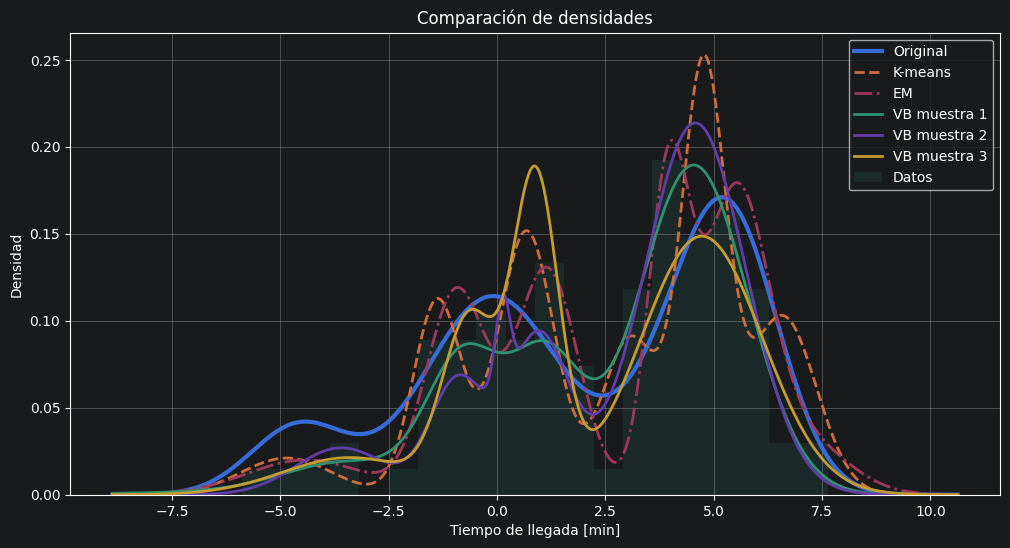

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    x,
    densidad_original,
    linewidth=3,
    label="Original"
)

plt.plot(
    x,
    densidad_kmeans,
    "--",
    linewidth=2,
    label="K-means"
)

plt.plot(
    x,
    densidad_em,
    "-.",
    linewidth=2,
    label="EM"
)

for i, densidad in enumerate(densidades_vb):

    plt.plot(
        x,
        densidad,
        linewidth=2,
        label=f"VB muestra {i+1}"
    )

plt.hist(
    muestras,
    bins=20,
    density=True,
    alpha=0.25,
    label="Datos"
)

plt.xlabel("Tiempo de llegada [min]")
plt.ylabel("Densidad")
plt.title("Comparación de densidades")
plt.grid(True)
plt.legend()

plt.show()

Se puede observar como las curvas generadas con GVB, con los 3 sets de parámetros generados se tiene curvas que ajustan mucho mejor a simple vista que las de Kmeans y EM, pero tambien se tiene otras que no logran ajustar tan bien.

## Distribución predictiva

Una vez finalizado el entrenamiento, la distribución predictiva no es una mezcla de gaussianas como en EM.

Al integrar los parámetros inciertos $\((\mu_k,\lambda_k)\)$, la predictiva de cada componente resulta ser una distribución t de Student.

La distribución predictiva total queda:

$$
P(x)
=
\sum_{k=1}^{K}
P(k)
\,P(x|k)
$$

donde

$$
P(k)
=
\frac{\alpha_k^*}
{\sum_j \alpha_j^*}
$$

y

$$
P(x|k)
=
\mathrm{St}
\left(
x
\;\middle|\;
m_k^*,
\frac{\beta_k^*(1+\delta_k^*)}
{\nu_k^*\delta_k^*},
2\nu_k^*
\right)
$$

In [15]:
densidad_predictiva = (
    gvb.predictive_predict_proba(
        x,
        normalize=False
    ).sum(axis=1)
)

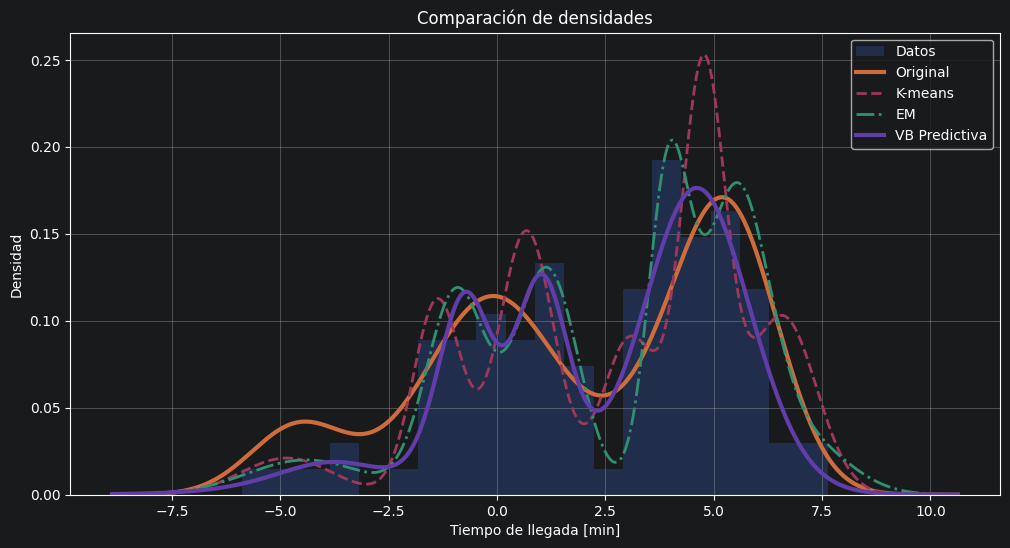

In [16]:
plt.figure(figsize=(12,6))

plt.hist(
    muestras.ravel(),
    bins=20,
    density=True,
    alpha=0.25,
    label="Datos"
)

plt.plot(
    x,
    densidad_original,
    linewidth=3,
    label="Original"
)

plt.plot(
    x,
    densidad_kmeans,
    "--",
    linewidth=2,
    label="K-means"
)

plt.plot(
    x,
    densidad_em,
    "-.",
    linewidth=2,
    label="EM"
)

plt.plot(
    x,
    densidad_predictiva,
    linewidth=3,
    label="VB Predictiva"
)

plt.xlabel("Tiempo de llegada [min]")
plt.ylabel("Densidad")
plt.title("Comparación de densidades")
plt.grid(True)
plt.legend()

plt.show()

Al generar una distrubución con el promedio de los parámetros se obtiene una distribución mucho más cercana a la original. 